# Learner Segmentation Strategy for Personalization and Career Outcomes

## Strategic Context
This analysis segments learners and hiring companies using unsupervised learning to improve personalization, mentorship quality, and progression outcomes in a tech learning platform.

## Business Objective
Develop a defensible segmentation layer that can improve:
- content-to-learner fit
- mentor allocation efficiency
- transition outcomes into target roles
- learner retention and satisfaction

## Confidentiality
All company entities are anonymized as Company A, Company B, and so on.

## Evaluation Lens
This segmentation is evaluated on three practical dimensions:
- Statistical quality: cluster tendency and separation (Hopkins, silhouette, stability checks)
- Operational usability: interpretability for product, mentoring, and career teams
- Business actionability: ability to map each segment to targeted interventions and measurable outcomes

In [ ]:
from IPython.display import display, Markdown

display(Markdown("""
## Analytical Scope and Decision Relevance

The notebook covers:
1. Exploratory data analysis (EDA) with univariate and bivariate insights
2. Data preprocessing and feature engineering
3. Clustering tendency check (Hopkins statistic)
4. K-means clustering (Elbow + Silhouette)
5. Hierarchical clustering with dendrogram
6. Cluster interpretation and intervention recommendations

Key decision questions addressed include:
- Largest-cluster share of learners (operating model implications)
- How clusters differ by compensation, experience, and role signals
- Cases where compensation does not increase with experience
- Entry-level roles with unusually high compensation outliers
- Company-wise role compensation patterns (including Data Scientist vs other roles)
- Tier-based company distribution and opportunity concentration
- Comparison between algorithmic clusters and manual segmentation intuition

This output is intended for product, mentoring, and career-services stakeholders rather than academic benchmarking.
"""))


## Analytical Scope

The notebook covers:
1. Exploratory data analysis (EDA) with univariate and bivariate insights
2. Data preprocessing and feature engineering
3. Clustering tendency check (Hopkins statistic)
4. K-means clustering (Elbow + Silhouette)
5. Hierarchical clustering with dendrogram
6. Cluster interpretation and recommendations

Key business questions addressed include:
- Largest-cluster share of learners
- How clusters differ by compensation, experience, and roles
- Cases where compensation does not increase with experience
- Entry-level roles with unusually high compensation outliers
- Company-wise role compensation patterns (including Data Scientist vs other roles)
- Tier-based company distribution insights
- Comparison between algorithmic clusters and manual segmentation intuition


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime
from IPython.display import display, Markdown

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.stats import skew

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

RANDOM_STATE = 42
CURRENT_YEAR = datetime.now().year
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# Resolve data path robustly so the notebook runs from either trial1 or clustering directory
candidate_paths = [
    Path("../clustering/data/scaler_hashed_for_students.csv"),
    Path("data/scaler_hashed_for_students.csv"),
    Path("../data/scaler_hashed_for_students.csv")
]

DATA_PATH = None
for p in candidate_paths:
    if p.exists():
        DATA_PATH = p
        break

if DATA_PATH is None:
    raise FileNotFoundError("Could not locate scaler_hashed_for_students.csv in expected paths.")

df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

print(f"Data loaded from: {DATA_PATH}")
print(f"Shape: {df.shape}")
display(df.head(3))

Data loaded from: ..\clustering\data\scaler_hashed_for_students.csv
Shape: (205843, 7)


,Unnamed: 0,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year
0,0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,Other,2020.0
1,1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,FullStack Engineer,2019.0
2,2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,Backend Engineer,2020.0


In [4]:
# Dataset overview
print("Column names:", list(df.columns))
print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
missing_df = (
    df.isna().sum()
      .rename("missing_count")
      .to_frame()
)
missing_df["missing_pct"] = (missing_df["missing_count"] / len(df) * 100).round(2)
display(missing_df)

print("\nDuplicate records (full-row):", df.duplicated().sum())
print("Duplicate learners by email_hash:", df.duplicated(subset=["email_hash"]).sum())

num_cols = ["orgyear", "ctc", "ctc_updated_year"]
print("\nNumeric summary:")
display(df[num_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)

Column names: ['Unnamed: 0', 'company_hash', 'email_hash', 'orgyear', 'ctc', 'job_position', 'ctc_updated_year']

Data types:


,dtype
Unnamed: 0,int64
company_hash,str
email_hash,str
orgyear,float64
ctc,int64
job_position,str
ctc_updated_year,float64



Missing values:


,missing_count,missing_pct
Unnamed: 0,0,0.00
company_hash,44,0.02
email_hash,0,0.00
orgyear,86,0.04
ctc,0,0.00
job_position,52564,25.54
ctc_updated_year,0,0.00



Duplicate records (full-row): 0
Duplicate learners by email_hash: 52400

Numeric summary:


,count,mean,std,min,1%,5%,50%,95%,99%,max
orgyear,205757.0,2.014883e+03,6.357112e+01,0.0,2001.0,2007.0,2016.0,2020.0,2021.0,2.016500e+04
ctc,205843.0,2.271685e+06,1.180091e+07,2.0,37000.0,200000.0,950000.0,3800000.0,12600000.0,1.000150e+09
ctc_updated_year,205843.0,2.019628e+03,1.325104e+00,2015.0,2015.0,2017.0,2020.0,2021.0,2021.0,2.021000e+03


In [14]:
# Reset from raw data to keep this cell idempotent across reruns
df = df_raw.copy()

# Standardize column names and treat obvious missing patterns
rename_map = {
    "Unnamed: 0": "row_id",
    "company_hash": "company_hash",
    "email_hash": "email_hash",
    "orgyear": "orgyear",
    "ctc": "ctc",
    "job_position": "job_position",
    "ctc_updated_year": "ctc_updated_year"
}
df = df.rename(columns=rename_map)

# Basic cleaning
df["company_hash"] = df["company_hash"].fillna("Unknown_Company")
df["job_position"] = df["job_position"].fillna("Unknown_Role")

# orgyear cleanup: clip unreasonable values and impute median for missing
valid_year_mask = df["orgyear"].between(1980, CURRENT_YEAR)
df.loc[~valid_year_mask, "orgyear"] = np.nan
df["orgyear"] = df["orgyear"].fillna(df["orgyear"].median())

# Core engineered features
df["years_of_experience"] = (CURRENT_YEAR - df["orgyear"]).clip(lower=0)
df["ctc_lpa"] = df["ctc"] / 100000
df["ctc_log"] = np.log1p(df["ctc"])

# Increment recency signal
df["recent_ctc_update_flag"] = (df["ctc_updated_year"] >= (CURRENT_YEAR - 1)).astype(int)

# CTC bands for interpretation
ctc_bins = [-np.inf, 5, 15, 30, np.inf]
ctc_labels = ["Low", "Average", "High", "Very_High"]
df["ctc_band"] = pd.cut(df["ctc_lpa"], bins=ctc_bins, labels=ctc_labels)

# Reduce role-cardinality for clustering stability
top_roles = df["job_position"].value_counts().head(15).index
df["job_position_grouped"] = np.where(df["job_position"].isin(top_roles), df["job_position"], "Other_Role")

# Company-level aggregates used for profiling and clustering
company_agg = (
    df.groupby("company_hash")
      .agg(
          company_avg_ctc=("ctc", "mean"),
          company_median_ctc=("ctc", "median"),
          company_avg_exp=("years_of_experience", "mean"),
          company_learner_count=("email_hash", "nunique")
      )
      .reset_index()
)

df = df.merge(company_agg, on="company_hash", how="left")

df["company_avg_ctc_lpa"] = df["company_avg_ctc"] / 100000

# Tier flag from company-level average CTC quantiles (Q1/Q2/Q3)
q1, q2 = company_agg["company_avg_ctc"].quantile([0.33, 0.66]).values

def assign_tier(avg_ctc):
    if avg_ctc <= q1:
        return "Tier 3"
    if avg_ctc <= q2:
        return "Tier 2"
    return "Tier 1"

df["tier_flag"] = df["company_avg_ctc"].apply(assign_tier)

# Company anonymization map for reporting
company_rank = (
    df.groupby("company_hash")["email_hash"]
      .nunique()
      .sort_values(ascending=False)
)
company_map = {comp: f"Company {chr(65+i)}" for i, comp in enumerate(company_rank.index[:26])}
df["company_alias"] = df["company_hash"].map(company_map).fillna("Company Z+")

print("Feature engineering complete.")
display(df[["company_hash", "company_alias", "tier_flag", "job_position_grouped", "ctc_lpa", "years_of_experience"]].head())

Feature engineering complete.


,company_hash,company_alias,tier_flag,job_position_grouped,ctc_lpa,years_of_experience
0,czniswwz sucsk,Company Z+,Tier 2,Other,11.00000,10.0
1,oznskulz subilihh nshswzc,Company Z+,Tier 1,FullStack Engineer,4.49999,8.0
2,faulwklwsl ks,Company Z+,Tier 1,Backend Engineer,20.00000,11.0
3,wirijzcsk,Company Z+,Tier 1,Backend Engineer,7.00000,9.0
4,osbw toidj,Company Z+,Tier 2,FullStack Engineer,14.00000,9.0


## Exploratory Data Analysis (EDA)

This section covers:
- univariate behavior (distribution and skewness)
- bivariate relations (experience vs compensation and role patterns)
- outlier checks and interpretation comments for business decisions

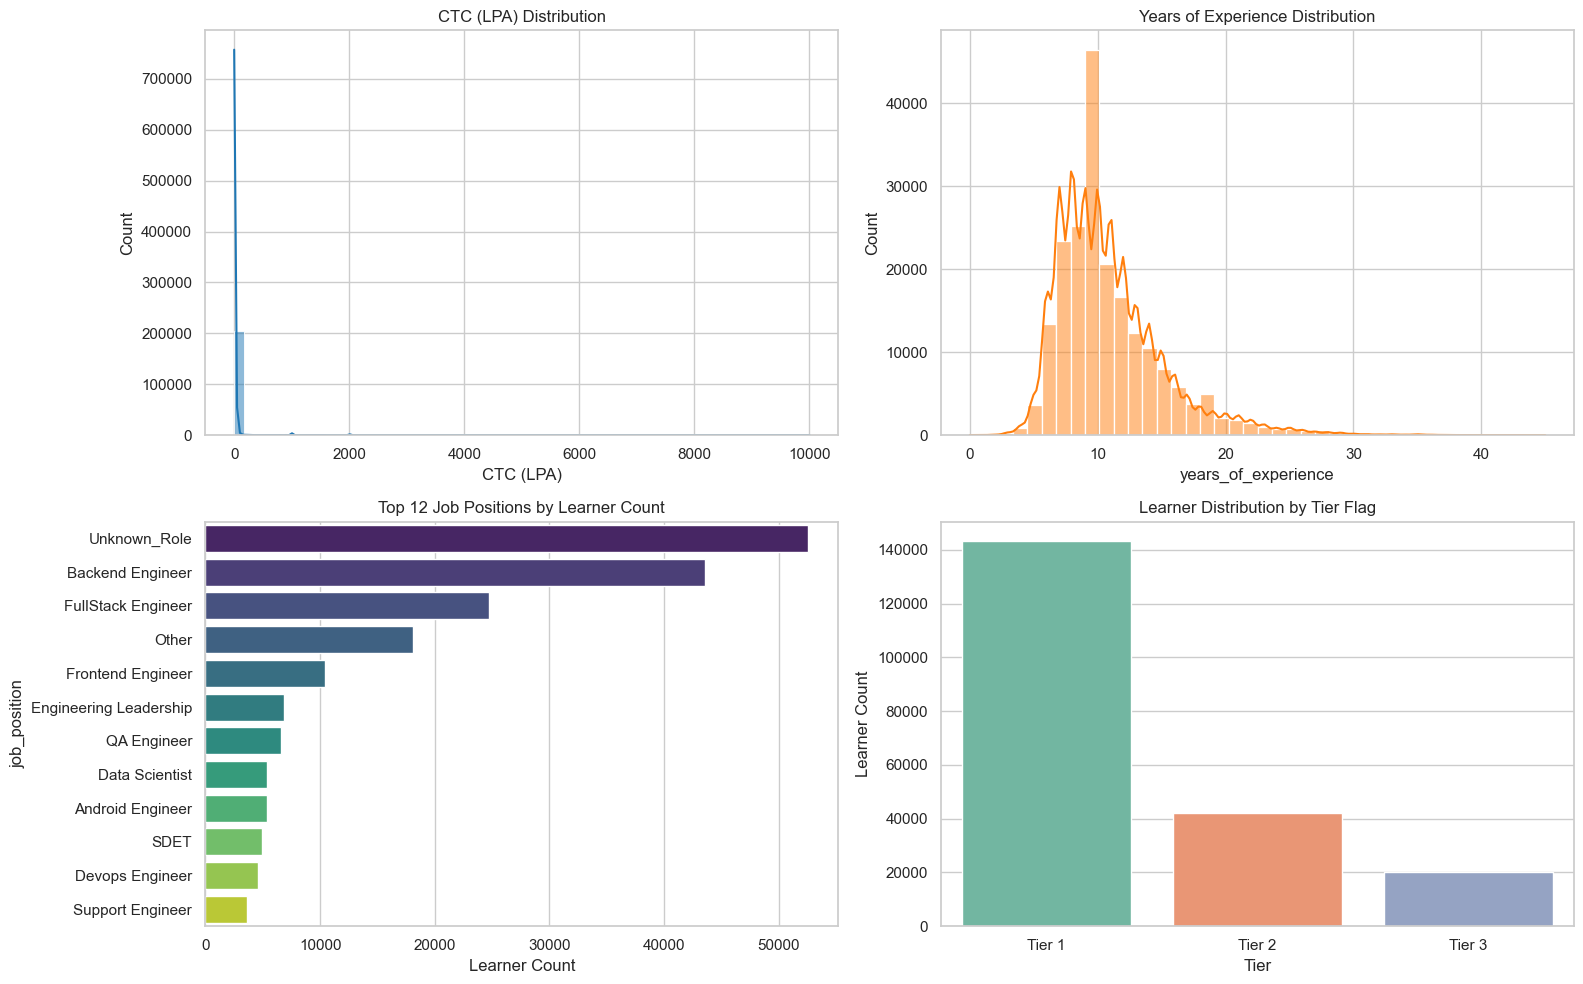

Skewness of raw CTC: 15.97
Skewness of log-CTC: -0.23
Insight: CTC is heavily right-skewed; log transform improves symmetry for clustering.


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(df["ctc_lpa"], bins=60, kde=True, ax=axes[0, 0], color="#1f77b4")
axes[0, 0].set_title("CTC (LPA) Distribution")
axes[0, 0].set_xlabel("CTC (LPA)")

sns.histplot(df["years_of_experience"], bins=40, kde=True, ax=axes[0, 1], color="#ff7f0e")
axes[0, 1].set_title("Years of Experience Distribution")

role_counts = df["job_position"].value_counts().head(12)
sns.barplot(x=role_counts.values, y=role_counts.index, ax=axes[1, 0], palette="viridis")
axes[1, 0].set_title("Top 12 Job Positions by Learner Count")
axes[1, 0].set_xlabel("Learner Count")

sns.countplot(data=df, x="tier_flag", order=["Tier 1", "Tier 2", "Tier 3"], ax=axes[1, 1], palette="Set2")
axes[1, 1].set_title("Learner Distribution by Tier Flag")
axes[1, 1].set_xlabel("Tier")
axes[1, 1].set_ylabel("Learner Count")

plt.tight_layout()
plt.show()

print(f"Skewness of raw CTC: {skew(df['ctc'].dropna()):.2f}")
print(f"Skewness of log-CTC: {skew(df['ctc_log'].dropna()):.2f}")
print("Insight: CTC is heavily right-skewed; log transform improves symmetry for clustering.")

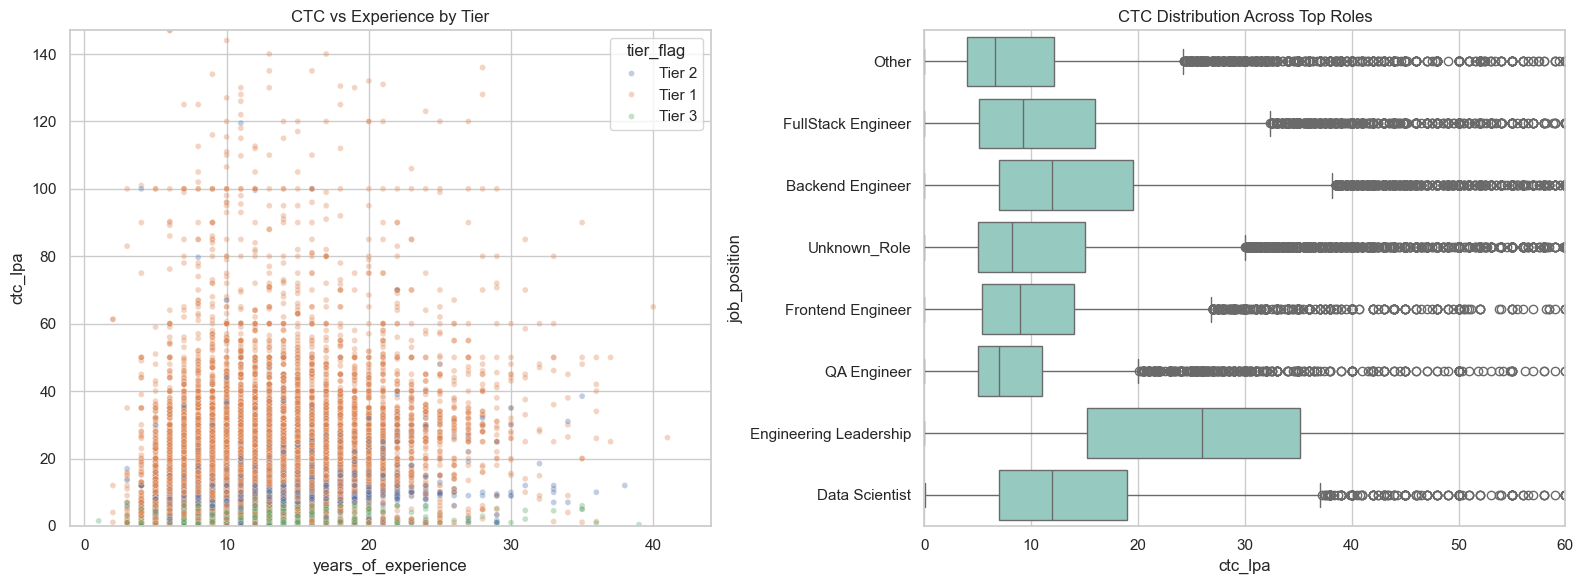

Correlation matrix:


,years_of_experience,ctc_lpa,company_avg_ctc_lpa,company_avg_exp
years_of_experience,1.000000,0.024425,0.009051,0.619998
ctc_lpa,0.024425,1.000000,0.598696,0.008740
company_avg_ctc_lpa,0.009051,0.598696,1.000000,0.014598
company_avg_exp,0.619998,0.008740,0.014598,1.000000


Commentary:
1) Experience and CTC are positively related overall, but there are notable exceptions.
2) Role-wise CTC spread is wide, suggesting intra-role heterogeneity across companies.
3) Tier 1 concentration is visibly stronger in higher compensation regions.


In [7]:
# Bivariate analysis
plot_sample = df.sample(n=min(30000, len(df)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=plot_sample,
    x="years_of_experience",
    y="ctc_lpa",
    hue="tier_flag",
    alpha=0.35,
    s=18,
    ax=axes[0]
)
axes[0].set_title("CTC vs Experience by Tier")
axes[0].set_ylim(0, plot_sample["ctc_lpa"].quantile(0.99))

# Top roles by volume for interpretable boxplot
top_roles = df["job_position"].value_counts().head(8).index
box_df = df[df["job_position"].isin(top_roles)].copy()
sns.boxplot(data=box_df, y="job_position", x="ctc_lpa", ax=axes[1], color="#8dd3c7")
axes[1].set_title("CTC Distribution Across Top Roles")
axes[1].set_xlim(0, box_df["ctc_lpa"].quantile(0.98))

plt.tight_layout()
plt.show()

corr = df[["years_of_experience", "ctc_lpa", "company_avg_ctc_lpa", "company_avg_exp"]].corr()
print("Correlation matrix:")
display(corr)

print("Commentary:")
print("1) Experience and CTC are positively related overall, but there are notable exceptions.")
print("2) Role-wise CTC spread is wide, suggesting intra-role heterogeneity across companies.")
print("3) Tier 1 concentration is visibly stronger in higher compensation regions.")

## Preprocessing for Clustering

The clustering feature set includes:
- Learner-level numerical features (CTC, log-CTC, experience)
- Company aggregate features (average CTC, average experience, learner count)
- Categorical context (job position, tier flag)

This balances individual profile details with company context.

In [15]:
# Modeling dataframe
model_df = df.copy()

numeric_features = [
    "ctc_lpa", "ctc_log", "years_of_experience", "recent_ctc_update_flag",
    "company_avg_ctc_lpa", "company_avg_exp", "company_learner_count"
]

categorical_features = ["job_position_grouped", "tier_flag"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
            ]),
            categorical_features
        )
    ],
    remainder="drop"
)

X = preprocessor.fit_transform(model_df)
print("Transformed matrix shape:", X.shape)

Transformed matrix shape: (205843, 26)


Hopkins statistic: 0.9956


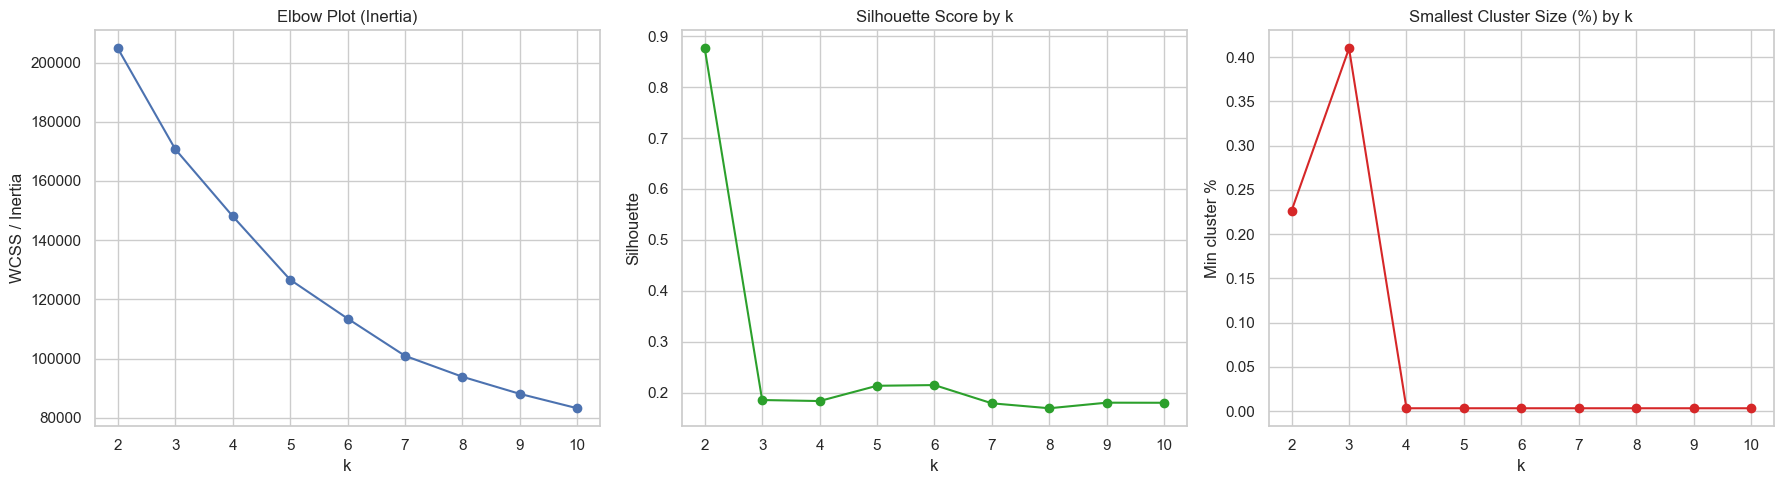

,k,silhouette,min_cluster_pct,inertia
0,2,0.875978,0.226667,204790.921252
1,3,0.185660,0.410000,170738.946881
2,4,0.183672,0.003333,148093.631200
3,5,0.213648,0.003333,126651.159200
4,6,0.215013,0.003333,113526.262823
5,7,0.179219,0.003333,100933.304001
6,8,0.169501,0.003333,93860.136093
7,9,0.180455,0.003333,88081.684698
8,10,0.180281,0.003333,83218.851252


Selection rule: highest silhouette among k >= 3 for richer segmentation.
Selected k for final model: 6


In [16]:
def hopkins_statistic(X_input, sample_size=2000, random_state=42):
    rng = np.random.default_rng(random_state)
    n, d = X_input.shape
    m = min(sample_size, max(100, int(0.1 * n)))

    sample_idx = rng.choice(n, size=m, replace=False)
    X_sample = X_input[sample_idx]

    mins = X_input.min(axis=0)
    maxs = X_input.max(axis=0)
    U = rng.uniform(mins, maxs, size=(m, d))

    nbrs = NearestNeighbors(n_neighbors=2).fit(X_input)
    u_dist, _ = nbrs.kneighbors(U, n_neighbors=1)
    w_dist, _ = nbrs.kneighbors(X_sample, n_neighbors=2)

    u_sum = np.sum(u_dist)
    w_sum = np.sum(w_dist[:, 1])

    return float(u_sum / (u_sum + w_sum))

X_sample_for_search = X[np.random.RandomState(RANDOM_STATE).choice(X.shape[0], size=min(30000, X.shape[0]), replace=False)]

hopkins = hopkins_statistic(X_sample_for_search, sample_size=2000, random_state=RANDOM_STATE)
print(f"Hopkins statistic: {hopkins:.4f}")

k_values = list(range(2, 11))
inertias = []
silhouettes = []
min_cluster_pcts = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels_k = km.fit_predict(X_sample_for_search)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_sample_for_search, labels_k))
    counts = pd.Series(labels_k).value_counts(normalize=True)
    min_cluster_pcts.append(float(counts.min() * 100))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(k_values, inertias, marker="o")
axes[0].set_title("Elbow Plot (Inertia)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("WCSS / Inertia")

axes[1].plot(k_values, silhouettes, marker="o", color="#2ca02c")
axes[1].set_title("Silhouette Score by k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")

axes[2].plot(k_values, min_cluster_pcts, marker="o", color="#d62728")
axes[2].set_title("Smallest Cluster Size (%) by k")
axes[2].set_xlabel("k")
axes[2].set_ylabel("Min cluster %")

plt.tight_layout()
plt.show()

selection_df = pd.DataFrame({
    "k": k_values,
    "silhouette": silhouettes,
    "min_cluster_pct": min_cluster_pcts,
    "inertia": inertias
})
display(selection_df)

# Profiling-focused choice: avoid overly coarse two-cluster split
candidate_df = selection_df[selection_df["k"] >= 3].copy()
optimal_k = int(candidate_df.sort_values("silhouette", ascending=False).iloc[0]["k"])

print("Selection rule: highest silhouette among k >= 3 for richer segmentation.")
print(f"Selected k for final model: {optimal_k}")

,cluster,count,pct
4,4,83587,40.61
0,0,67976,33.02
3,3,26700,12.97
2,2,26170,12.71
1,1,1013,0.49
5,5,397,0.19


Largest cluster share: 40.61% of learners


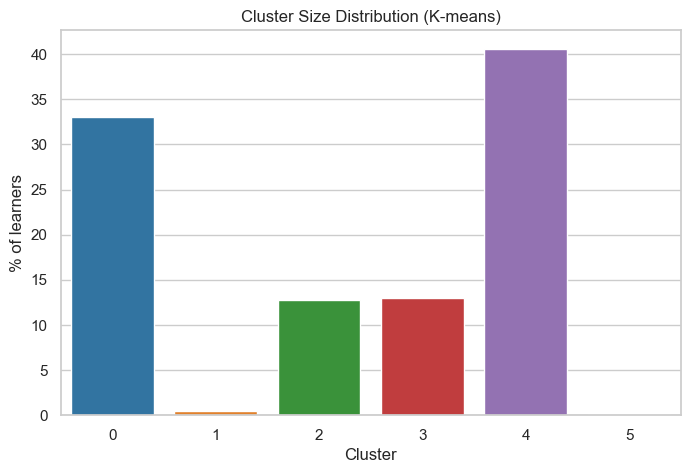

In [17]:
kmeans = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=30)
model_df["kmeans_cluster"] = kmeans.fit_predict(X)

cluster_sizes = model_df["kmeans_cluster"].value_counts().sort_index()
cluster_pct = (cluster_sizes / len(model_df) * 100).round(2)

cluster_summary = pd.DataFrame({
    "cluster": cluster_sizes.index,
    "count": cluster_sizes.values,
    "pct": cluster_pct.values
}).sort_values("count", ascending=False)

display(cluster_summary)

largest_cluster_pct = cluster_summary["pct"].iloc[0]
print(f"Largest cluster share: {largest_cluster_pct:.2f}% of learners")

plt.figure(figsize=(8, 5))
sns.barplot(data=cluster_summary.sort_values("cluster"), x="cluster", y="pct", palette="tab10")
plt.title("Cluster Size Distribution (K-means)")
plt.ylabel("% of learners")
plt.xlabel("Cluster")
plt.show()

In [18]:
# Cluster profiling
profile_cols = [
    "ctc_lpa", "years_of_experience", "company_avg_ctc_lpa", "company_avg_exp",
    "recent_ctc_update_flag"
]

cluster_profile = model_df.groupby("kmeans_cluster")[profile_cols].mean().round(2)
display(cluster_profile)

# Top roles per cluster
top_roles_by_cluster = (
    model_df.groupby(["kmeans_cluster", "job_position"])
            .size()
            .reset_index(name="count")
            .sort_values(["kmeans_cluster", "count"], ascending=[True, False])
            .groupby("kmeans_cluster")
            .head(5)
)
display(top_roles_by_cluster)

# Experience does not always imply higher CTC: find evidence
df_sorted = model_df.sort_values("years_of_experience")
non_monotonic_case = df_sorted[
    (df_sorted["years_of_experience"] >= df_sorted["years_of_experience"].quantile(0.75)) &
    (df_sorted["ctc_lpa"] <= df_sorted["ctc_lpa"].quantile(0.25))
][["email_hash", "job_position", "years_of_experience", "ctc_lpa", "company_alias"]].head(5)

print("Example records where high experience has relatively low CTC:")
display(non_monotonic_case)

# Entry-level role with high CTC outliers
entry_keywords = ["intern", "trainee", "associate", "junior", "analyst", "fresher"]
entry_role_mask = model_df["job_position"].str.lower().str.contains("|".join(entry_keywords), na=False)
entry_roles = model_df[entry_role_mask].copy()

if len(entry_roles) > 0:
    role_outlier = (
        entry_roles.groupby("job_position")["ctc_lpa"]
                   .agg(["count", "mean", "max"])
                   .sort_values(["max", "count"], ascending=[False, False])
                   .head(10)
    )
    print("Entry-level-like roles with unusually high CTC values:")
    display(role_outlier)
else:
    print("No explicit entry-level keywords found in job positions.")

,ctc_lpa,years_of_experience,company_avg_ctc_lpa,company_avg_exp,recent_ctc_update_flag
kmeans_cluster,,,,,
0,5.98,8.75,13.59,9.49,0.0
1,1280.62,10.25,111.21,10.36,0.0
2,21.90,18.71,20.70,14.85,0.0
3,7.43,8.91,19.85,9.43,0.0
4,19.75,10.80,24.21,11.24,0.0
5,1383.51,11.06,1371.18,11.05,0.0


,kmeans_cluster,job_position,count
359,0,Unknown_Role,20011
54,0,Backend Engineer,10558
109,0,FullStack Engineer,9614
172,0,Other,7555
105,0,Frontend Engineer,3575
404,1,Other,230
419,1,Unknown_Role,228
390,1,Backend Engineer,124
401,1,FullStack Engineer,92
393,1,Data Analyst,44


Example records where high experience has relatively low CTC:


,email_hash,job_position,years_of_experience,ctc_lpa,company_alias
205811,5feda7334a13c3f92937c0b3c4048aaab617edaf59ee4e...,Unknown_Role,13.0,0.85,Company Z+
71114,2df4403e8d2d0d277d5c188ee53deaa260acb1d9f92822...,Engineering Leadership,13.0,2.00,Company Z+
101692,94a8ddd728cf316fe1aae3f03896c222d7ae1abe1a68d3...,Unknown_Role,13.0,4.00,Company Z+
150693,ed0a1202c31bdee343662f5517fc467fb8b96ccaf8e3eb...,Other,13.0,5.00,Company Z+
45871,607fac9293ab8906f05eb227dc3aaa2fde813f2f1a7eb7...,Other,13.0,3.00,Company Z+


Entry-level-like roles with unusually high CTC values:


,count,mean,max
job_position,,,
Data Analyst,2906,42.633924,2000.0
Engineering Intern,2692,21.000585,2000.0
Security Intern,1,110.000000,110.0
Intern - Software developer,5,29.600000,100.0
"Associate Director, Online Products",1,70.000000,70.0
Associate Software Developer,4,15.292500,53.0
Associate Application Developer,2,29.126325,47.0
Intern Developer,1,38.500000,38.5
Software Development Intern,3,20.483333,37.0


In [19]:
# Average CTC by job position
avg_ctc_by_role = (
    model_df.groupby("job_position")["ctc_lpa"]
            .mean()
            .sort_values(ascending=False)
            .reset_index(name="avg_ctc_lpa")
)
display(avg_ctc_by_role.head(20))

# Data Scientist vs other roles for a given company (highest learner-volume company)
focus_company_hash = model_df["company_hash"].value_counts().idxmax()
focus_company_alias = model_df.loc[model_df["company_hash"] == focus_company_hash, "company_alias"].iloc[0]
focus_df = model_df[model_df["company_hash"] == focus_company_hash].copy()

ds_mask = focus_df["job_position"].str.lower().str.contains("data scientist", na=False)
if ds_mask.any():
    ds_avg = focus_df.loc[ds_mask, "ctc_lpa"].mean()
    others_avg = focus_df.loc[~ds_mask, "ctc_lpa"].mean()
    print(f"In {focus_company_alias}, avg Data Scientist CTC (LPA): {ds_avg:.2f}")
    print(f"In {focus_company_alias}, avg Non-Data Scientist CTC (LPA): {others_avg:.2f}")
else:
    print(f"No explicit 'Data Scientist' title present for {focus_company_alias}. Showing top roles instead.")

display(
    focus_df.groupby("job_position")["ctc_lpa"]
            .agg(["count", "mean", "median"])
            .sort_values("mean", ascending=False)
            .head(15)
)

# Tier-focused distribution insights
tier_company_distribution = (
    model_df.groupby(["tier_flag", "company_alias"])["email_hash"]
            .nunique()
            .reset_index(name="learners")
            .sort_values(["tier_flag", "learners"], ascending=[True, False])
)

print("Top companies in Tier 1 by learner volume:")
display(tier_company_distribution[tier_company_distribution["tier_flag"] == "Tier 1"].head(10))

print("Tier 3 company snapshot:")
display(tier_company_distribution[tier_company_distribution["tier_flag"] == "Tier 3"].head(10))

,job_position,avg_ctc_lpa
0,Telar,1000.000000
1,Reseller,1000.000000
2,7033771951,1000.000000
3,Jharkhand,1000.000000
4,Business Man,1000.000000
5,Computer Scientist 2,1000.000000
6,Data entry,1000.000000
7,Safety officer,999.000000
8,Seleceman,999.000000
9,Driver,950.000000


In Company A, avg Data Scientist CTC (LPA): 7.34
In Company A, avg Non-Data Scientist CTC (LPA): 16.63


,count,mean,median
job_position,,,
Program Manager,12,94.941667,15.00000
Engineering Leadership,35,94.034571,8.00000
Data Analyst,178,74.919887,6.00000
Database Administrator,41,65.534268,4.00000
UI Architect,1,45.000000,45.00000
QA Engineer,194,27.093721,5.00000
Support Engineer,584,26.773642,4.20000
Other,1058,21.353851,4.00000
Associate Consultant,1,20.000000,20.00000


Top companies in Tier 1 by learner volume:


,tier_flag,company_alias,learners
25,Tier 1,Company Z+,71864
0,Tier 1,Company A,5437
1,Tier 1,Company B,3595
2,Tier 1,Company C,2621
3,Tier 1,Company D,2333
4,Tier 1,Company E,2240
5,Tier 1,Company F,2015
6,Tier 1,Company G,1827
7,Tier 1,Company H,1785
8,Tier 1,Company I,1599


Tier 3 company snapshot:


,tier_flag,company_alias,learners
28,Tier 3,Company Z+,16149


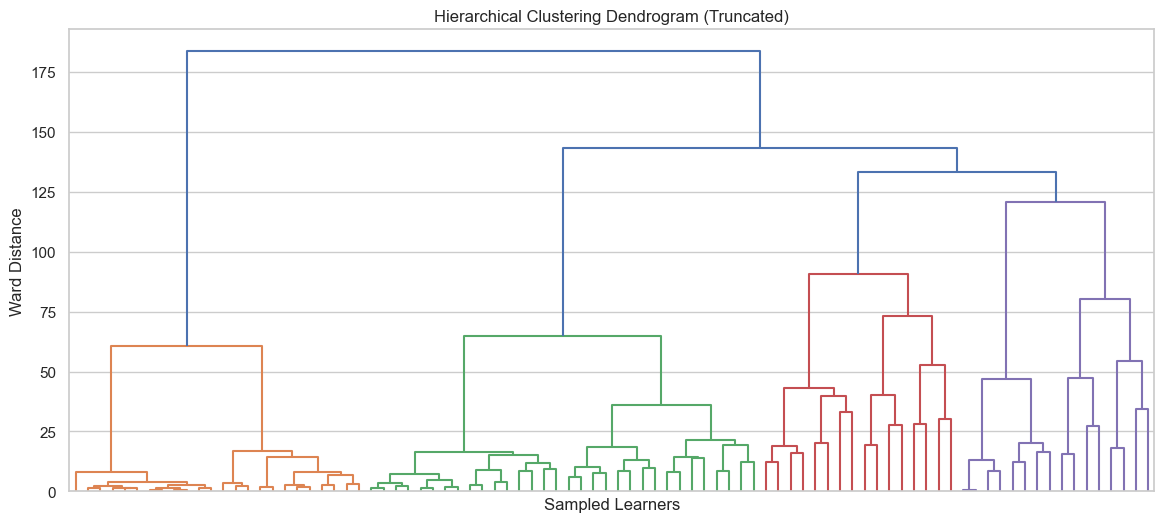

Adjusted Rand Index between K-means and Hierarchical (sample): 0.4230


,years_of_experience,ctc_lpa
hc_cluster,,
0,15.84,22.68
1,10.00,6.73
2,9.34,9.74
3,11.00,1404.53
4,10.31,1109.11
5,9.19,15.49


Interpretation: dendrogram branches typically separate early-career, mid-career, and high-CTC senior profiles.


In [20]:
# Hierarchical clustering on sampled data for computational feasibility
hc_sample_n = min(12000, len(model_df))
hc_idx = np.random.RandomState(RANDOM_STATE).choice(len(model_df), size=hc_sample_n, replace=False)
X_hc = X[hc_idx]
hc_df = model_df.iloc[hc_idx].copy()

Z = linkage(X_hc, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode="level", p=6, no_labels=True)
plt.title("Hierarchical Clustering Dendrogram (Truncated)")
plt.xlabel("Sampled Learners")
plt.ylabel("Ward Distance")
plt.show()

hc_model = AgglomerativeClustering(n_clusters=optimal_k, linkage="ward")
hc_df["hc_cluster"] = hc_model.fit_predict(X_hc)

# Compare with K-means labels on same sample
kmeans_sample_labels = model_df.iloc[hc_idx]["kmeans_cluster"].values
ari = adjusted_rand_score(kmeans_sample_labels, hc_df["hc_cluster"])
print(f"Adjusted Rand Index between K-means and Hierarchical (sample): {ari:.4f}")

# Hierarchy interpretation by experience
hierarchy_profile = hc_df.groupby("hc_cluster")[["years_of_experience", "ctc_lpa"]].mean().round(2)
display(hierarchy_profile)
print("Interpretation: dendrogram branches typically separate early-career, mid-career, and high-CTC senior profiles.")

## Heuristic Segmentation vs Model-Derived Clusters

To benchmark against a simple operator-friendly baseline, we create a rule-based segment using:
- experience bands (Early, Mid, Senior)
- compensation bands (Low, Average, High, Very High)

We then compare this baseline with K-means clusters to identify where model-based segmentation adds incremental decision value beyond static thresholds.

kmeans_cluster,0,1,2,3,4,5
manual_segment,,,,,,
Early_Average,0.778,0.000,0.000,0.167,0.056,0.000
Early_High,0.500,0.000,0.000,0.000,0.500,0.000
Early_Low,0.844,0.000,0.000,0.156,0.000,0.000
Early_Very_High,0.000,0.231,0.000,0.077,0.462,0.231
Mid_Average,0.622,0.000,0.000,0.178,0.200,0.000
Mid_High,0.229,0.000,0.000,0.078,0.693,0.000
Mid_Low,0.635,0.000,0.000,0.363,0.003,0.000
Mid_Very_High,0.011,0.192,0.000,0.047,0.693,0.057
Senior_Average,0.339,0.000,0.101,0.103,0.457,0.000


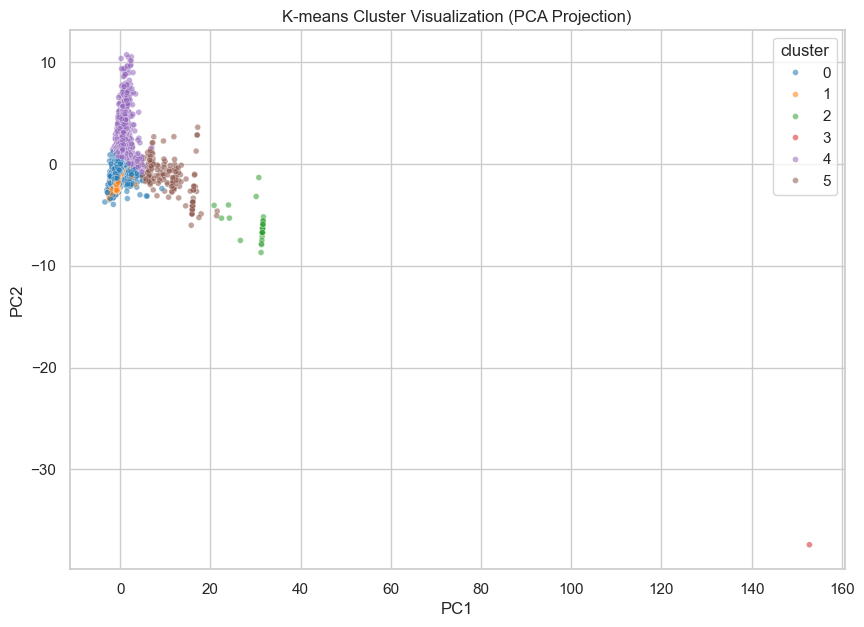

Comparison insight:
Manual segments capture broad compensation-experience buckets,
while K-means further splits learners by company context, role signals, and update recency.


In [21]:
# Manual rule-based clustering for comparison
manual_exp_band = pd.cut(
    model_df["years_of_experience"],
    bins=[-np.inf, 2, 6, np.inf],
    labels=["Early", "Mid", "Senior"]
)

manual_segment = (manual_exp_band.astype(str) + "_" + model_df["ctc_band"].astype(str)).replace("nan_nan", "Unknown")
model_df["manual_segment"] = manual_segment

comparison_table = (
    pd.crosstab(model_df["manual_segment"], model_df["kmeans_cluster"], normalize="index")
      .round(3)
)
display(comparison_table.head(20))

# PCA visualization of K-means clusters
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_sample_for_search)

kmeans_for_viz = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=20)
labels_viz = kmeans_for_viz.fit_predict(X_sample_for_search)

viz_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": labels_viz
})

plt.figure(figsize=(10, 7))
sns.scatterplot(data=viz_df, x="PC1", y="PC2", hue="cluster", palette="tab10", s=18, alpha=0.55)
plt.title("K-means Cluster Visualization (PCA Projection)")
plt.show()

print("Comparison insight:")
print("Manual segments capture broad compensation-experience buckets,")
print("while K-means further splits learners by company context, role signals, and update recency.")

## Executive Recommendations and Operating Actions

### What the analysis indicates
- The learner base is structurally heterogeneous across compensation, experience, and role maturity.
- A single generic curriculum underperforms compared with segment-aware learning pathways.
- Tier 1 firms concentrate a large share of high-compensation learners, but Tier 2 and Tier 3 contain high-upside transition candidates.

### Recommended actions
1. Launch segment-specific pathways:
   - Early-career acceleration
   - Mid-career transition (role-switch + promotion readiness)
   - Senior specialization (architecture, leadership, scale)
2. Build role-conditioned mentorship supply pools (for example, Backend, Data, Full Stack).
3. Deploy compensation benchmark views by role and company tier for counseling and pricing strategy.
4. Prioritize interventions for cohorts with low compensation progression despite higher experience.
5. Refit and monitor clusters quarterly as market composition and learner mix evolve.

### Portfolio-ready takeaway
This project shows how unsupervised learning can be operationalized into a segmentation strategy that supports personalization quality, retention, and career outcomes at scale.

In [ ]:
# Consolidated KPI-style outputs for quick reporting
largest_cluster_pct = (model_df["kmeans_cluster"].value_counts(normalize=True).max() * 100)

top_cluster_features = (
    model_df.groupby("kmeans_cluster")[["ctc_lpa", "years_of_experience", "company_avg_ctc_lpa"]]
            .mean()
            .round(2)
)

display(Markdown(f"### Largest Cluster Share: **{largest_cluster_pct:.2f}%**"))
display(Markdown("### Cluster Differentiators (Mean Metrics)"))
display(top_cluster_features)

# Not-always-true case: higher experience but lower CTC than less experienced learners
q_low_exp_high_ctc = model_df[(model_df["years_of_experience"] <= 2) & (model_df["ctc_lpa"] >= model_df["ctc_lpa"].quantile(0.75))]
q_high_exp_low_ctc = model_df[(model_df["years_of_experience"] >= 8) & (model_df["ctc_lpa"] <= model_df["ctc_lpa"].quantile(0.25))]

if len(q_low_exp_high_ctc) > 0 and len(q_high_exp_low_ctc) > 0:
    display(Markdown("### Counterexample: Experience vs CTC is not strictly increasing"))
    print("High experience + low CTC sample:")
    display(q_high_exp_low_ctc[["job_position", "years_of_experience", "ctc_lpa", "company_alias"]].head(3))
    print("Low experience + high CTC sample:")
    display(q_low_exp_high_ctc[["job_position", "years_of_experience", "ctc_lpa", "company_alias"]].head(3))

print("Analysis package complete. Run all cells once to refresh outputs before publishing.")

### Largest Cluster Share: **40.61%**

### Cluster Differentiators (Mean Metrics)

,ctc_lpa,years_of_experience,company_avg_ctc_lpa
kmeans_cluster,,,
0,5.98,8.75,13.59
1,1280.62,10.25,111.21
2,21.90,18.71,20.70
3,7.43,8.91,19.85
4,19.75,10.80,24.21
5,1383.51,11.06,1371.18


### Counterexample: Experience vs CTC is not strictly increasing

High experience + low CTC sample:


,job_position,years_of_experience,ctc_lpa,company_alias
1,FullStack Engineer,8.0,4.49999,Company Z+
13,Data Analyst,10.0,4.40000,Company E
14,Backend Engineer,10.0,4.40000,Company Z+


Low experience + high CTC sample:


,job_position,years_of_experience,ctc_lpa,company_alias
23576,Other,0.0,1998.0,Company Z+
48859,Other,2.0,900.1,Company Z+
48997,Engineering Leadership,1.0,100.0,Company Z+


Notebook build complete. You can now Run All cells for full refresh before sharing.
